In [131]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import multivariate_normal

# Caminho relativo (funciona de qualquer lugar)
# data_path = Path("..") / "data" / "raw" / "gaussianas.csv"
# df = pd.read_csv(data_path)

In [140]:
def plot_grid(data, labels):
    fig, ax = plt.subplots()
    plt.scatter(data[:, 0], data[:, 1], c=labels, cmap="viridis", edgecolor="k")
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title("Dados Gaussianos")
    plt.grid()
    plt.show()


def gen_data(params: dict) -> np.ndarray:
    """Gera um DataFrame com duas classes de dados gaussianos."""

    mean1 = params["mean1"]
    mean2 = params["mean2"]
    cov = params["cov"]
    priors = params["priors"]
    n_samples = params["n_samples"]
    seed = params["seed"]

    assert round(sum(priors), 2) == 1, "Os priors devem somar 1."

    class_1_pdf = multivariate_normal(mean1, cov)
    class_2_pdf = multivariate_normal(mean2, cov)

    class_1_samples = class_1_pdf.rvs(int(n_samples * priors[0]), random_state=seed)
    class_2_samples = class_2_pdf.rvs(int(n_samples * priors[1]), random_state=seed)

    data = np.vstack((class_1_samples, class_2_samples))
    labels = np.array([0] * len(class_1_samples) + [1] * len(class_2_samples))

    # Trocar amostragem por .rvs para gerar amostras de forma analitica.

    return data, labels


def get_posterior(params: dict, x):
    """Calcula a probabilidade a posteriori usando a distribuição normal multivariada."""
    prob_1 = multivariate_normal.pdf(x, mean=params["mean1"], cov=params["cov"])
    prob_2 = multivariate_normal.pdf(x, mean=params["mean2"], cov=params["cov"])

    return np.stack([prob_1, prob_2], axis=1)


# Pensar no caso de 100 classes. Pensar na forma vetorial e broadcast.


def get_preds(x, params):

    posteriors = get_posterior(params, x)
    predicions = np.argmax(posteriors * params["priors"], axis=1)
    confidence = np.max(posteriors * params["priors"], axis=1)
    return predicions, confidence

    # Argmax da posterior
    # Func de confiança chow, rank de probabilidade.

In [141]:
params = {
    "mean1": (0, 0),
    "mean2": (1, 1),
    "cov": [[1, 0], [0, 1]],
    "priors": [0.5, 0.5],
    "n_samples": 100,
    "seed": 77,
}

data, labels = gen_data(params)

classifications, posteriors = get_preds(data, params)
classifications, posteriors

(array([0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
        0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0,
        1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1]),
 array([0.06234798, 0.06189977, 0.01015729, 0.02213559, 0.01788805,
        0.06170704, 0.02849071, 0.01628564, 0.03418523, 0.07834484,
        0.06204871, 0.04442745, 0.00171809, 0.05123739, 0.05566178,
        0.01101373, 0.07338424, 0.02797221, 0.07514521, 0.02958388,
        0.04563422, 0.06718595, 0.05672961, 0.07846238, 0.04247983,
        0.01206329, 0.05885419, 0.0665845 , 0.04370931, 0.01510336,
        0.04840059, 0.05668024, 0.01030352, 0.06787815, 0.06619123,
        0.03878031, 0.03666489, 0.07779895, 0.07753257, 0.05253602,
        0.06581188, 0.05542274, 0.03457941, 0.04035979, 0.03647197,
        0.07882646, 0.06014327, 0.04455945, 0.

Acurácia: 0.78


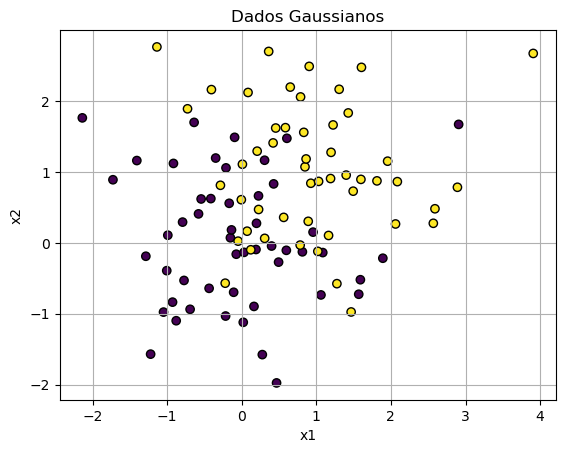

In [134]:
accuracy = np.mean(classifications == labels)
print(f"Acurácia: {accuracy:.2f}")

plot_grid(data, labels)

In [ ]:
# plot RC curve.

# rank de probabilidade, func de confiança